# En este doc vamos a realizar las comparativas de  cada uno de los modelos de spacy 

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import umap.umap_ as umap
import spacy
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from scipy.cluster.hierarchy import dendrogram, linkage

/Users/31almawolf/Documents/FiltroLimpio/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## - Modelo de NLP local con configuracion para el idioma chino

### Preparacion de los datos para su analisis

In [31]:
df_test = pd.read_csv("Test_dataset/chino_test.csv")

print(f"Dataset de test cargado correctamente con {len(df_test)} textos.")

print("Generando vectores con tu modelo spaCy...")
nlp_vectores = spacy.load("zh_core_web_trf")

vectors = []
for doc in nlp_vectores.pipe(df_test['text'], batch_size=256):
    if doc._.trf_data is not None:
        trf_matrix = doc._.trf_data.last_hidden_layer_state.data
        doc_vector = trf_matrix.mean(axis=0) 
        vectors.append(doc_vector)
    else:
        vectors.append(np.zeros(768))

X_vectors = np.array(vectors)

print("Escalando los vectores...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vectors)

print("Reduciendo dimensiones a 2D usando UMAP...")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(X_scaled)

df_test['x_umap'] = embedding_2d[:, 0]
df_test['y_umap'] = embedding_2d[:, 1]

Dataset de test cargado correctamente con 5000 textos.
Generando vectores con tu modelo spaCy...
Escalando los vectores...
Reduciendo dimensiones a 2D usando UMAP...


/Users/31almawolf/Documents/FiltroLimpio/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### - Representación de clusters

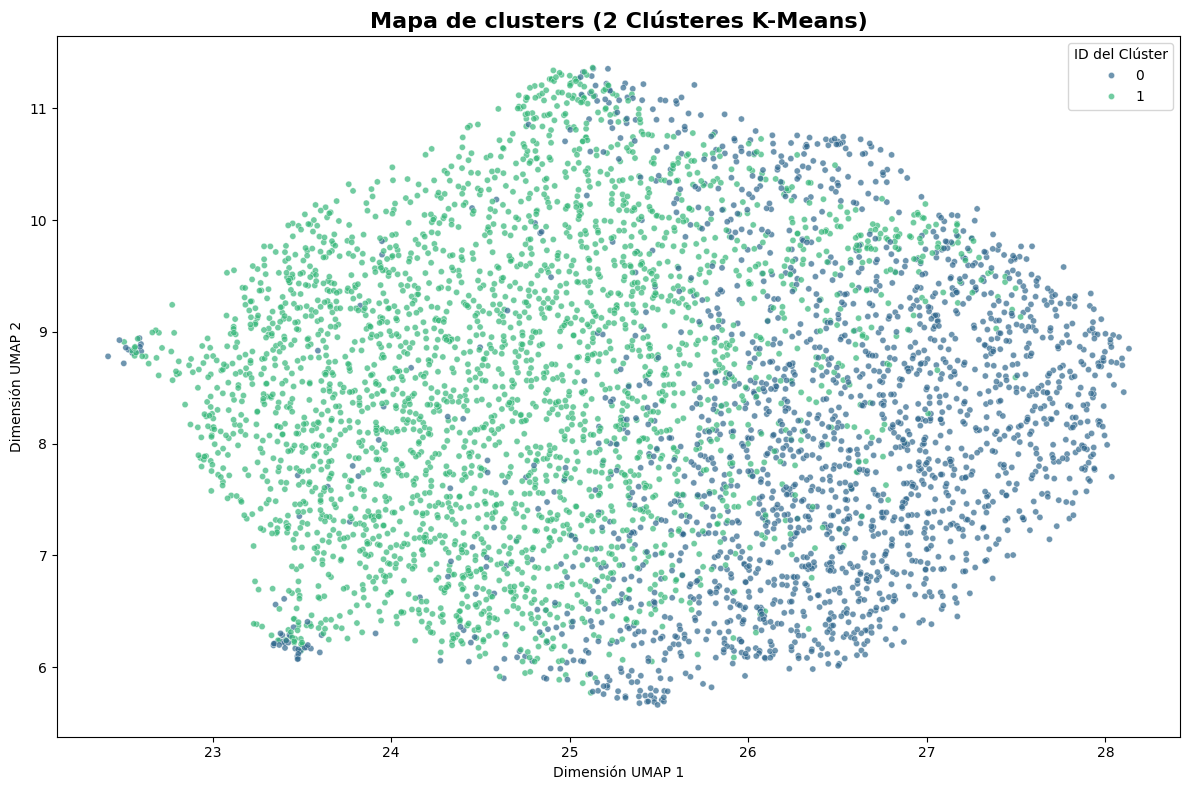

In [ ]:
N_CLUSTERS = 2

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
df_test['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='x_umap', y='y_umap',
    hue='kmeans_cluster', 
    palette='viridis',   
    data=df_test,
    s=20, alpha=0.7, 
    legend='full'
)
plt.title(f'Mapa de clusters ({N_CLUSTERS} Clústeres K-Means)', fontsize=16, fontweight='bold')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.legend(title='ID del Clúster')
plt.tight_layout()
plt.show()

# print(f"\n--- Ejemplos de textos por Clúster K-Means (para interpretar la Gráfica 1) ---")
# for i in range(N_CLUSTERS):
#     print(f"\n[CLÚSTER {i}]: Ejemplo de contenido:")
#     examples = df_test[df_test['kmeans_cluster'] == i]['text'].head(3).tolist()
#     for ex in examples:
#         print(f"  - {ex[:100]}")

### - Buscador de Anomalías

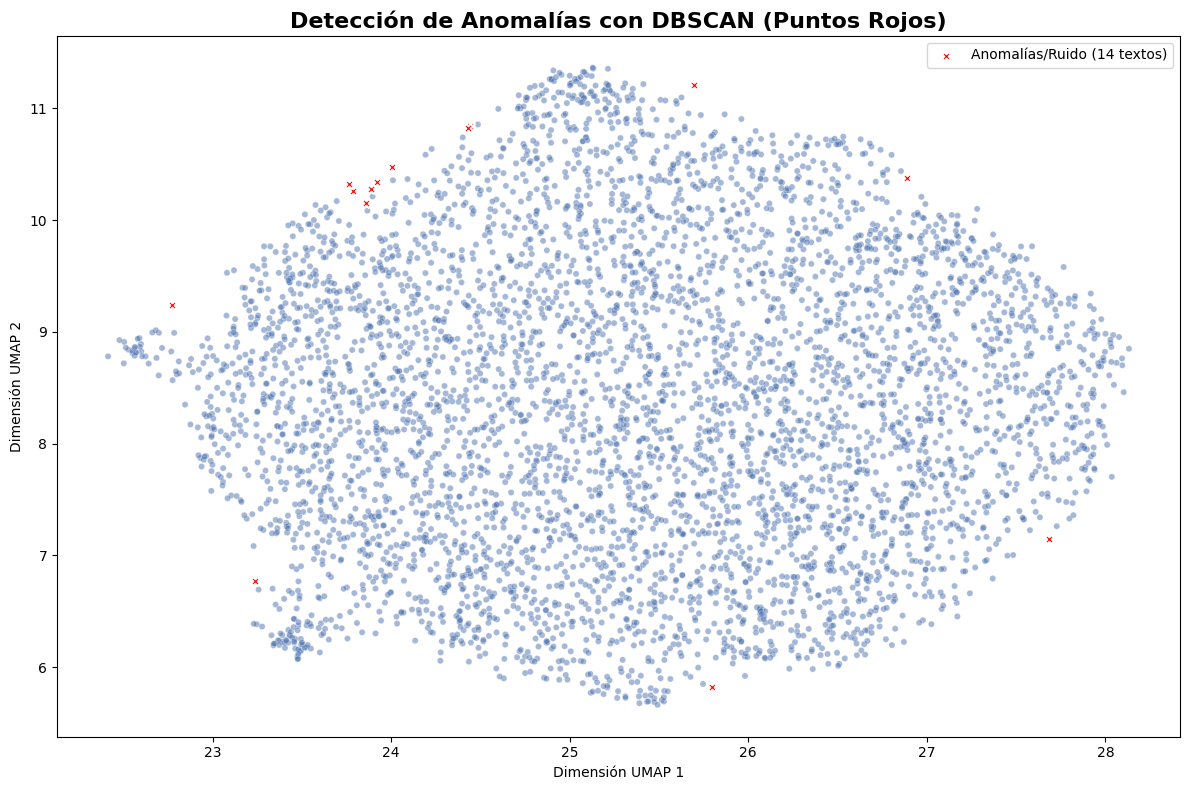


--- Ejemplos de Anomalías detectadas por DBSCAN---
  - 江西不配被黑
  - 安徽主要是在上海被歧视
  - 呃……上海经济好吧，还不是照样黑
  - 如此完美？哈哈哈，就胸前那干瘪的半两肉嘛


In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=15)
df_test['dbscan_cluster'] = dbscan.fit_predict(embedding_2d)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='x_umap', y='y_umap',
    hue='dbscan_cluster',
    palette='deep',
    data=df_test[df_test['dbscan_cluster'] != -1],
    s=20, alpha=0.5, legend=False
)

noise_data = df_test[df_test['dbscan_cluster'] == -1]
sns.scatterplot(
    x='x_umap', y='y_umap',
    color='#FF0000',
    marker='X',   
    s=40, linewidth=1.5,
    label=f'Anomalías/Ruido ({len(noise_data)} textos)',
    data=noise_data
)

plt.title('Detección de Anomalías con DBSCAN (Puntos Rojos)', fontsize=16, fontweight='bold')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.legend()
plt.tight_layout()
plt.show()

if len(noise_data) > 0:
    print(f"\n--- Ejemplos de Anomalías detectadas por DBSCAN---")
    example = noise_data['text'].head(4).tolist()
    for ex in example:
        print(f"  - {ex[:300]}")

### - Puntos Ciegos del nlp

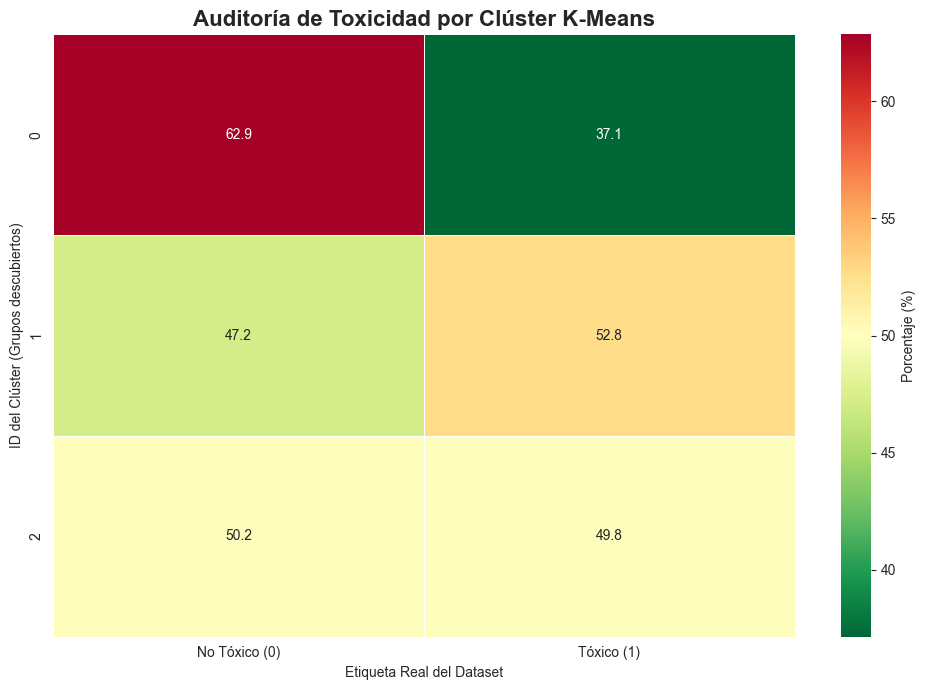

In [ ]:
labels_map = {0: 'No Tóxico (0)', 1: 'Tóxico (1)'}
crosstab_norm = pd.crosstab(
    df_test['kmeans_cluster'],
    df_test['label'].map(labels_map),
    normalize='index'
) * 100

plt.figure(figsize=(10, 7))
heatmap = sns.heatmap(
    crosstab_norm,
    annot=True,  
    fmt=".1f",   
    cmap="RdYlGn_r",
    linewidths=.5,
    cbar_kws={'label': 'Porcentaje (%)'}
)
plt.title('Auditoría de Toxicidad por Clúster K-Means', fontsize=16, fontweight='bold')
plt.ylabel('ID del Clúster (Grupos descubiertos)')
plt.xlabel('Etiqueta Real del Dataset')
plt.tight_layout()
plt.show()


### - Matriz de Confusión

/Users/31almawolf/Documents/FiltroLimpio/venv/lib/python3.11/site-packages/thinc/shims/pytorch.py:118: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type="cuda", enabled=self._mixed_precision):


{'TOXICO': 0.741306722164154, 'NO_TOXICO': 0.2586933374404907}
{'TOXICO': 0.04545341432094574, 'NO_TOXICO': 0.9545465707778931}
{'TOXICO': 0.7300494313240051, 'NO_TOXICO': 0.26995062828063965}
{'TOXICO': 0.9750632047653198, 'NO_TOXICO': 0.02493681013584137}
{'TOXICO': 0.27033674716949463, 'NO_TOXICO': 0.7296632528305054}
{'TOXICO': 0.2998510003089905, 'NO_TOXICO': 0.7001489400863647}
{'TOXICO': 0.888619601726532, 'NO_TOXICO': 0.1113804280757904}
{'TOXICO': 0.10481682419776917, 'NO_TOXICO': 0.8951831459999084}
{'TOXICO': 0.9799511432647705, 'NO_TOXICO': 0.020048869773745537}
{'TOXICO': 0.9370134472846985, 'NO_TOXICO': 0.06298653036355972}
{'TOXICO': 0.2442266345024109, 'NO_TOXICO': 0.7557733654975891}
{'TOXICO': 0.8621206283569336, 'NO_TOXICO': 0.13787932693958282}
{'TOXICO': 0.8079802989959717, 'NO_TOXICO': 0.1920197308063507}
{'TOXICO': 0.8294457793235779, 'NO_TOXICO': 0.1705542355775833}
{'TOXICO': 0.03747699782252312, 'NO_TOXICO': 0.9625229835510254}
{'TOXICO': 0.6611999869346619, '

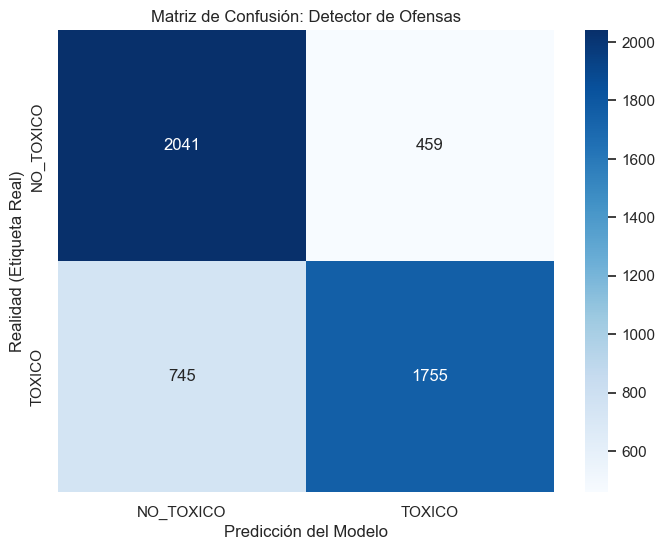

In [6]:
sns.set_theme(style="whitegrid") 
plt.rcParams['figure.dpi'] = 100

nlp = spacy.load("nlp_chino/output_zh/model-best")

test_data = pd.read_csv("Test_dataset/chino_test.csv")
test_data = test_data.dropna(subset=['text'])
test_data['label'] = test_data['label'].astype(int)

y_true = []
y_pred = []
true_label = ""
resultados = []

for text, label in zip(test_data['text'], test_data['label']):
    doc = nlp(text)
    print(doc.cats)
    pred_label = max(doc.cats, key=doc.cats.get)
    resultados.append({
        'frase': text,
        'toxic_pct': doc.cats['TOXICO'],
        'non_toxic_pct': doc.cats['NO_TOXICO']
    })

    if label == 1:
        true_label = "TOXICO"
    else:
        true_label = "NO_TOXICO"
    
    y_true.append(true_label)
    y_pred.append(pred_label)

df = pd.DataFrame(resultados)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred))

labels = ["NO_TOXICO", "TOXICO"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.title('Matriz de Confusión: Detector de Ofensas')
plt.show()

### -Dendrograma

/var/folders/kj/1dt3mjg13cg79wq2mb6k9v6h0000gn/T/ipykernel_5504/3795111758.py:38: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kj/1dt3mjg13cg79wq2mb6k9v6h0000gn/T/ipykernel_5504/3795111758.py:38: UserWarning: Glyph 40857 (\N{CJK UNIFIED IDEOGRAPH-9F99}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kj/1dt3mjg13cg79wq2mb6k9v6h0000gn/T/ipykernel_5504/3795111758.py:38: UserWarning: Glyph 27743 (\N{CJK UNIFIED IDEOGRAPH-6C5F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kj/1dt3mjg13cg79wq2mb6k9v6h0000gn/T/ipykernel_5504/3795111758.py:38: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kj/1dt3mjg13cg79wq2mb6k9v6h0000gn/T/ipykernel_5504/3795111758.py:38: UserWarning: Glyph 36824 (\N{CJK UNIFIED IDEOGRAPH-8FD8}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kj/1dt3mjg13cg79wq2mb6k9v6h0000gn/T/ipyker

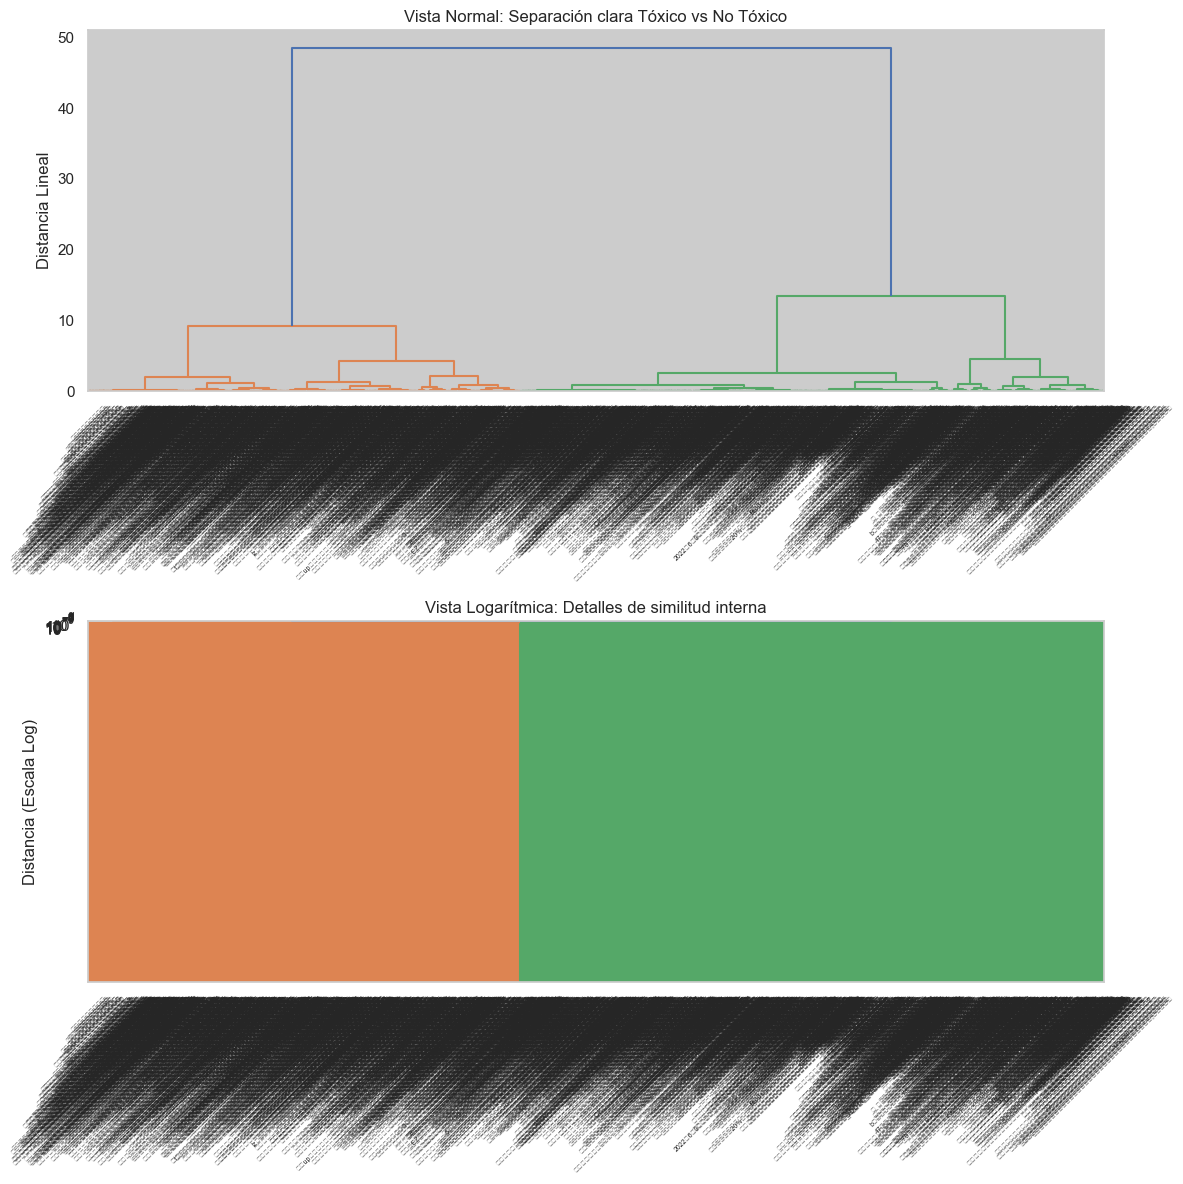

In [ ]:
nlp = spacy.load("nlp_español/output_es/model-last")

# palabras_test = [
#     "Eres una persona increible", "Te quiero mucho", "Amistad verdadera",
#     "Eres un idiota", "Vaya basura de servicio", "Eres un inutil",
#     "Gracias por tu ayuda", "Que buen dia hace", "Te odio maldito", "No te odio", ""
# ]

# resultados = []

# for frase in palabras_test:
#     res = nlp(frase)
#     print(res.cats)
#     resultados.append({
#         'frase': frase,
#         'toxic_pct': res.cats['TOXICO'],
#         'non_toxic_pct': res.cats['NO_TOXICO']
#     })

# df = pd.DataFrame(resultados)
X = df[['toxic_pct', 'non_toxic_pct']].values
X = X + np.random.normal(0, 0.000001, X.shape)
Z = linkage(X, method='ward')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

dendrogram(Z, labels=df['frase'].values, leaf_rotation=45, ax=ax1)
ax1.set_title('Vista Normal: Separación clara Tóxico vs No Tóxico')
ax1.set_ylabel('Distancia Lineal')

dendrogram(Z, labels=df['frase'].values, leaf_rotation=45)
ax2.set_yscale("log")
ax2.set_title('Vista Logarítmica: Detalles de similitud interna')
ax2.set_ylabel('Distancia (Escala Log)')

plt.tight_layout()
plt.show()


/Users/31almawolf/Documents/FiltroLimpio/venv/lib/python3.11/site-packages/thinc/shims/pytorch.py:118: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type="cuda", enabled=self._mixed_precision):


{'TOXICO': 0.741306722164154, 'NO_TOXICO': 0.2586933374404907}
{'TOXICO': 0.04545341432094574, 'NO_TOXICO': 0.9545465707778931}
{'TOXICO': 0.7300494313240051, 'NO_TOXICO': 0.26995062828063965}
{'TOXICO': 0.9750632047653198, 'NO_TOXICO': 0.02493681013584137}
{'TOXICO': 0.27033674716949463, 'NO_TOXICO': 0.7296632528305054}
{'TOXICO': 0.2998510003089905, 'NO_TOXICO': 0.7001489400863647}
{'TOXICO': 0.888619601726532, 'NO_TOXICO': 0.1113804280757904}
{'TOXICO': 0.10481682419776917, 'NO_TOXICO': 0.8951831459999084}
{'TOXICO': 0.9799511432647705, 'NO_TOXICO': 0.020048869773745537}
{'TOXICO': 0.9370134472846985, 'NO_TOXICO': 0.06298653036355972}
{'TOXICO': 0.2442266345024109, 'NO_TOXICO': 0.7557733654975891}
{'TOXICO': 0.8621206283569336, 'NO_TOXICO': 0.13787932693958282}
{'TOXICO': 0.8079802989959717, 'NO_TOXICO': 0.1920197308063507}
{'TOXICO': 0.8294457793235779, 'NO_TOXICO': 0.1705542355775833}
{'TOXICO': 0.03747699782252312, 'NO_TOXICO': 0.9625229835510254}
{'TOXICO': 0.6611999869346619, '

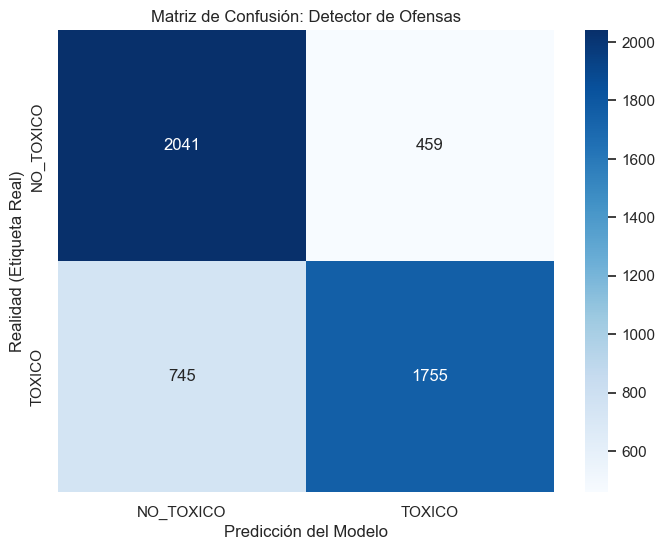

In [6]:
sns.set_theme(style="whitegrid") 
plt.rcParams['figure.dpi'] = 100

nlp = spacy.load("nlp_chino/output_zh/model-best")

test_data = pd.read_csv("Test_dataset/chino_test.csv")
test_data = test_data.dropna(subset=['text'])
test_data['label'] = test_data['label'].astype(int)

y_true = []
y_pred = []
true_label = ""
resultados = []

for text, label in zip(test_data['text'], test_data['label']):
    doc = nlp(text)
    print(doc.cats)
    pred_label = max(doc.cats, key=doc.cats.get)
    resultados.append({
        'frase': text,
        'toxic_pct': doc.cats['TOXICO'],
        'non_toxic_pct': doc.cats['NO_TOXICO']
    })

    if label == 1:
        true_label = "TOXICO"
    else:
        true_label = "NO_TOXICO"
    
    y_true.append(true_label)
    y_pred.append(pred_label)

df = pd.DataFrame(resultados)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred))

labels = ["NO_TOXICO", "TOXICO"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.title('Matriz de Confusión: Detector de Ofensas')
plt.show()

### - Gráfica de Densidad

In [ ]:
df['clase'] = df['toxic_pct'].apply(lambda x: 'Tóxico' if x > 0.5 else 'No Tóxico')

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(data=df, x="toxic_pct", hue="clase", kde=True, stat="count")

plt.title('Distribución de Probabilidades de Toxicidad (KDE)', fontsize=14)
plt.xlabel('Probabilidad de Toxicidad (0 a 1)', fontsize=12)
plt.ylabel('Numero de frases', fontsize=12)
plt.xlim(0, 1) 

plt.show()

NameError: name 'df' is not defined

## - Modelo de NLP local con configuracion para el idioma español

### (Preparación de los textos para su analisis)

In [ ]:
df_test = pd.read_csv("Test_dataset/español_test.csv")

print(f"Dataset de test cargado correctamente con {len(df_test)} textos.")

print("Generando vectores con tu modelo spaCy...")
nlp_vectores = spacy.load("es_dep_news_trf")

vectors = []
for doc in nlp_vectores.pipe(df_test['text'], batch_size=256):
    if doc._.trf_data is not None:
        trf_matrix = doc._.trf_data.last_hidden_layer_state.data
        doc_vector = trf_matrix.mean(axis=0) 
        vectors.append(doc_vector)
    else:
        vectors.append(np.zeros(768))

X_vectors = np.array(vectors)
print("Escalando los vectores...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vectors)

print("Reduciendo dimensiones a 2D usando UMAP...")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(X_scaled)

df_test['x_umap'] = embedding_2d[:, 0]
df_test['y_umap'] = embedding_2d[:, 1]

Dataset de test cargado correctamente con 5000 textos.
Generando vectores con tu modelo spaCy...


KeyboardInterrupt: 

#### Busqueda del K mas prometedor

                                                   text  label    x_umap  \
0     A este tambien lo habia que echar porque era u...      1  4.219654   
1     la mañana coincidió que charlando de mis labio...      1  3.124555   
2     El vídeo del que todo el mundo habla XD « Jord...      1  6.890517   
3     del peor error de mexico queda claro que fue u...      1  5.667475   
4           antes de irme a trabajar la abuela me folla      1  3.142601   
...                                                 ...    ...       ...   
4995  ¡Nooooooooooo!  Eso, listillo, despertarís a l...      0  7.679542   
4996  Oramas cree que el riesgo independentista desa...      0  7.905736   
4997  Esquerra Unida reclama la retirada del monolit...      0  7.865870   
4998  [SPOILER DE THE WALKING DEAD]... ¡¿PERO QUE CO...      0  7.535480   
4999  Odio las palomitas y su malsana afición de per...      0  5.306973   

        y_umap  kmeans_cluster  
0    -3.417697               3  
1    -4.210357       

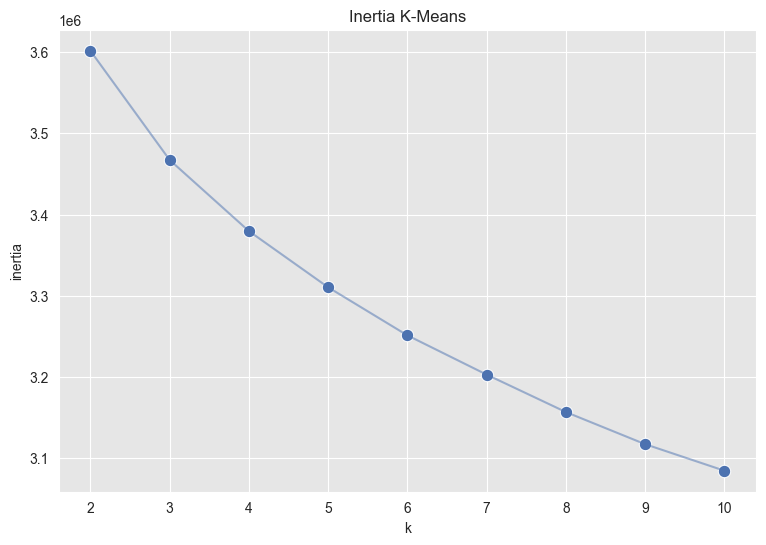

In [ ]:
from sklearn.cluster import KMeans
sns.set_style('darkgrid', {'axes.facecolor': '.9'})
sns.set_palette(palette='deep')
sns_c = sns.color_palette(palette='deep')

inertias = []

print(df_test)

k_candidates = list(range(2,11))


for k in k_candidates:
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10)
 
    k_means.fit(X_scaled)
 
    inertias.append(k_means.inertia_)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(x=k_candidates, y = inertias, s=80, ax=ax)

sns.lineplot(x=k_candidates, y = inertias, alpha=0.5, ax=ax)
ax.set(title='Inertia K-Means', ylabel='inertia', xlabel='k');

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40000 stored elements and shape (5000, 5000)>
  Coords	Values
  (0, 4270)	1.0
  (0, 3895)	1.0
  (0, 2287)	1.0
  (0, 2914)	1.0
  (0, 1934)	1.0
  (0, 3815)	1.0
  (0, 540)	1.0
  (0, 1260)	1.0
  (1, 4209)	1.0
  (1, 4647)	1.0
  (1, 4187)	1.0
  (1, 2072)	1.0
  (1, 3792)	1.0
  (1, 4374)	1.0
  (1, 4705)	1.0
  (1, 4247)	1.0
  (2, 2457)	1.0
  (2, 3123)	1.0
  (2, 4922)	1.0
  (2, 4921)	1.0
  (2, 408)	1.0
  (2, 4827)	1.0
  (2, 2755)	1.0
  (2, 4115)	1.0
  (3, 408)	1.0
  :	:
  (4996, 4771)	1.0
  (4997, 4996)	1.0
  (4997, 4838)	1.0
  (4997, 4795)	1.0
  (4997, 4772)	1.0
  (4997, 4889)	1.0
  (4997, 4935)	1.0
  (4997, 4805)	1.0
  (4997, 4771)	1.0
  (4998, 4874)	1.0
  (4998, 4798)	1.0
  (4998, 4928)	1.0
  (4998, 4751)	1.0
  (4998, 4854)	1.0
  (4998, 4883)	1.0
  (4998, 4934)	1.0
  (4998, 4759)	1.0
  (4999, 532)	1.0
  (4999, 4496)	1.0
  (4999, 3116)	1.0
  (4999, 4146)	1.0
  (4999, 224)	1.0
  (4999, 3281)	1.0
  (4999, 2943)	1.0
  (4999, 3140)	1.0


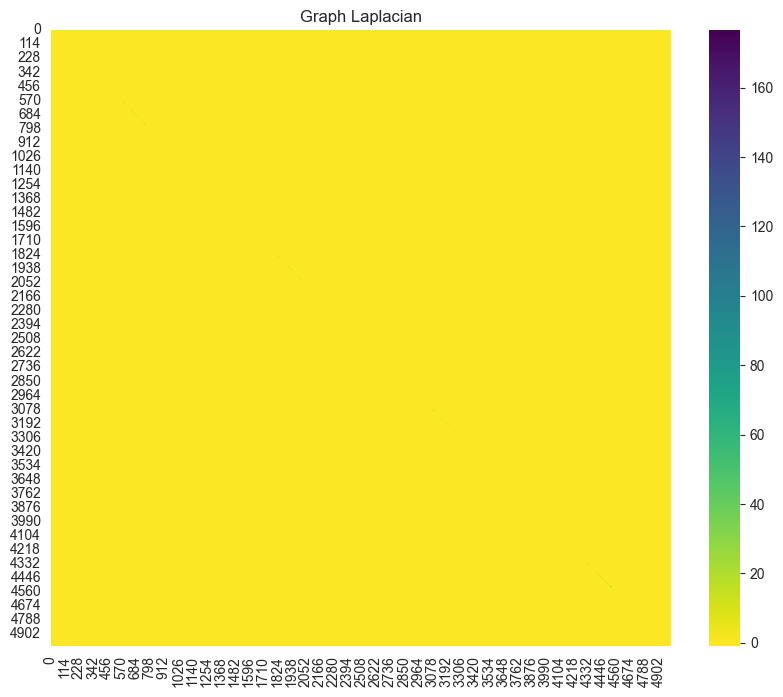

In [ ]:
from sklearn.neighbors import kneighbors_graph
from scipy import sparse
#numero de vecinos
nn=8

connectivity = kneighbors_graph(X=X_scaled, n_neighbors=nn, mode='connectivity')
print(connectivity)
# Adjacency Matrix W.   Suma connectivity a su traspuesta y divide entre 2
adjacency_matrix_s = (connectivity + connectivity.T) / 2 
print("-------")
print()
print(adjacency_matrix_s)

# Graph Laplacian.
graph_laplacian_s = sparse.csgraph.laplacian(csgraph=adjacency_matrix_s, normed=False)

#convierte la matriz en un array usando el método toarray()
graph_laplacian = graph_laplacian_s.toarray()
    
# Plot the graph Laplacian as heat map.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(graph_laplacian, ax=ax, cmap='viridis_r')
ax.set(title='Graph Laplacian');

In [ ]:
from scipy import linalg

eigenvals, eigenvcts = linalg.eig(graph_laplacian)

np.unique(np.imag(eigenvals))

eigenvals = np.real(eigenvals)
eigenvcts = np.real(eigenvcts)

from sklearn.preprocessing import normalize


eigenvals_sorted_indices = np.argsort(eigenvals)
eigenvals_sorted = eigenvals[eigenvals_sorted_indices]

#Comprobamos que los tres primeros autovalores son aproximadamente 0
zero_eigenvals_index = np.argwhere(abs(eigenvals_sorted) < 1e-5)
print(zero_eigenvals_index )
print("***************")


#También ordenamos los autovectores

indices = eigenvals_sorted_indices[: 3]


proj_df = pd.DataFrame(eigenvcts[:, indices])

print(proj_df)

proj_df.columns = ['v_' + str(c) for c in proj_df.columns]

#normalizamos la filas
proj_df = pd.DataFrame(normalize(proj_df, norm='l2', axis=1))
print("-+-+-+-+")
print(proj_df)


[[0]]
***************
             0         1         2
0    -0.014142 -0.003012  0.003009
1    -0.014142 -0.003086  0.006655
2    -0.014142  0.012601  0.000081
3    -0.014142  0.000107  0.003187
4    -0.014142 -0.002907  0.009050
...        ...       ...       ...
4995 -0.014142  0.079441  0.002063
4996 -0.014142  0.105814 -0.006344
4997 -0.014142  0.103303 -0.005860
4998 -0.014142  0.073914  0.000766
4999 -0.014142 -0.003599 -0.011596

[5000 rows x 3 columns]
-+-+-+-+
             0         1         2
0    -0.957558 -0.203925  0.203711
1    -0.887687 -0.193692  0.417726
2    -0.746615  0.665242  0.004267
3    -0.975512  0.007394  0.219822
4    -0.829952 -0.170627  0.531099
...        ...       ...       ...
4995 -0.175208  0.984200  0.025565
4996 -0.132239  0.989441 -0.059323
4997 -0.135421  0.989198 -0.056116
4998 -0.187913  0.982133  0.010178
4999 -0.758737 -0.193081 -0.622123

[5000 rows x 3 columns]


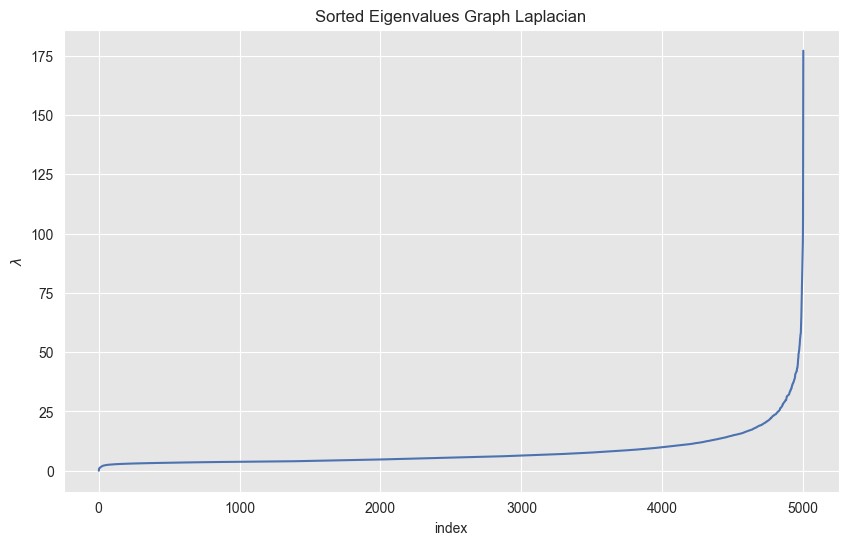

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=range(1, eigenvals_sorted_indices.size + 1), y=eigenvals_sorted, ax=ax)
ax.set(title='Sorted Eigenvalues Graph Laplacian', xlabel='index', ylabel=r'$\lambda$');

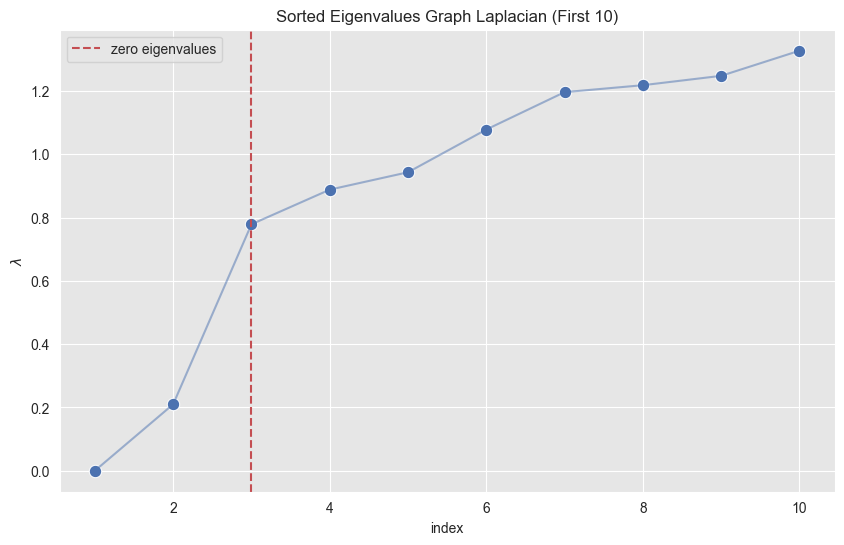

In [ ]:
index_lim = 10

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=range(1, eigenvals_sorted_indices[: index_lim].size + 1), y=eigenvals_sorted[: index_lim], s=80, ax=ax)
sns.lineplot(x=range(1, eigenvals_sorted_indices[: index_lim].size + 1), y=eigenvals_sorted[: index_lim], alpha=0.5, ax=ax)
ax.axvline(x=3, color=sns_c[3], label='zero eigenvalues', linestyle='--')
ax.legend()
ax.set(title=f'Sorted Eigenvalues Graph Laplacian (First {index_lim})', xlabel='index', ylabel=r'$\lambda$');

### - Representación de clusters

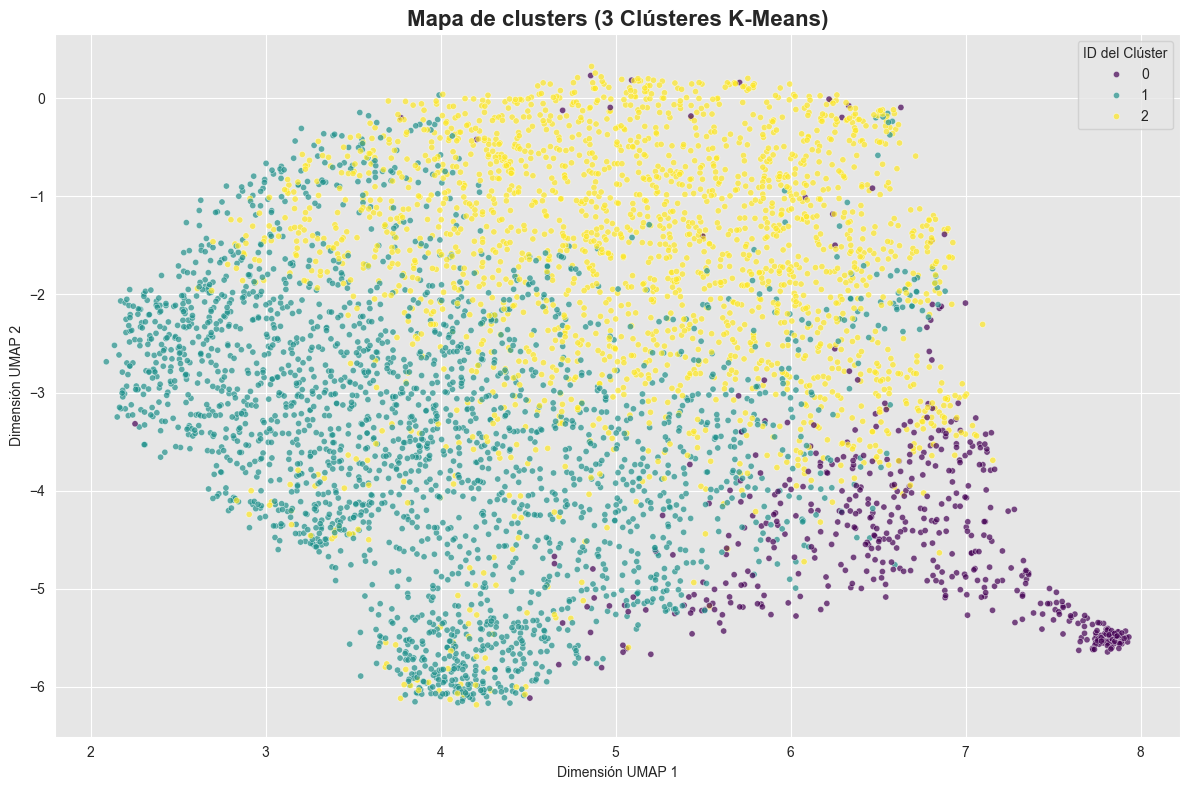


--- Ejemplos de textos por Clúster K-Means---

[CLÚSTER 0]: Ejemplo de contenido:
  - El vídeo del que todo el mundo habla XD « Jordi Porn – Todos los videos de Jordi el polla – Web NO O
  - Sexo lésbico es trampa sexual
  - hacele un favor al mundo y morite

[CLÚSTER 1]: Ejemplo de contenido:
  - A este tambien lo habia que echar porque era una puta mierda, como Cumic
  - la mañana coincidió que charlando de mis labios, en sus brazos y le metió un dedo en el baño aqui la
  - del peor error de mexico queda claro que fue un fosil de la unam, y el chocoflan va a escuela privad

[CLÚSTER 2]: Ejemplo de contenido:
  - Para mí, la única diferencia que hay entre estas y las que están en la Bolita del Mundo es que las ú
  - Ahora se llena esto de gentuza kasposa catalufa y vascolufa
  - Al Chino le precede ese agrio olor a carne podrida y macerada en salsa de ostras incorruptas


In [ ]:
N_CLUSTERS = 3

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
df_test['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='x_umap', y='y_umap',
    hue='kmeans_cluster', 
    palette='viridis',   
    data=df_test,
    s=20, alpha=0.7, 
    legend='full'
)
plt.title(f'Mapa de clusters ({N_CLUSTERS} Clústeres K-Means)', fontsize=16, fontweight='bold')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.legend(title='ID del Clúster')
plt.tight_layout()
plt.show()

print(f"\n--- Ejemplos de textos por Clúster K-Means---")
for i in range(N_CLUSTERS):
    print(f"\n[CLÚSTER {i}]: Ejemplo de contenido:")
    examples = df_test[df_test['kmeans_cluster'] == i]['text'].head(3).tolist()
    for ex in examples:
        print(f"  - {ex[:100]}")

### - Buscador de Anomalías

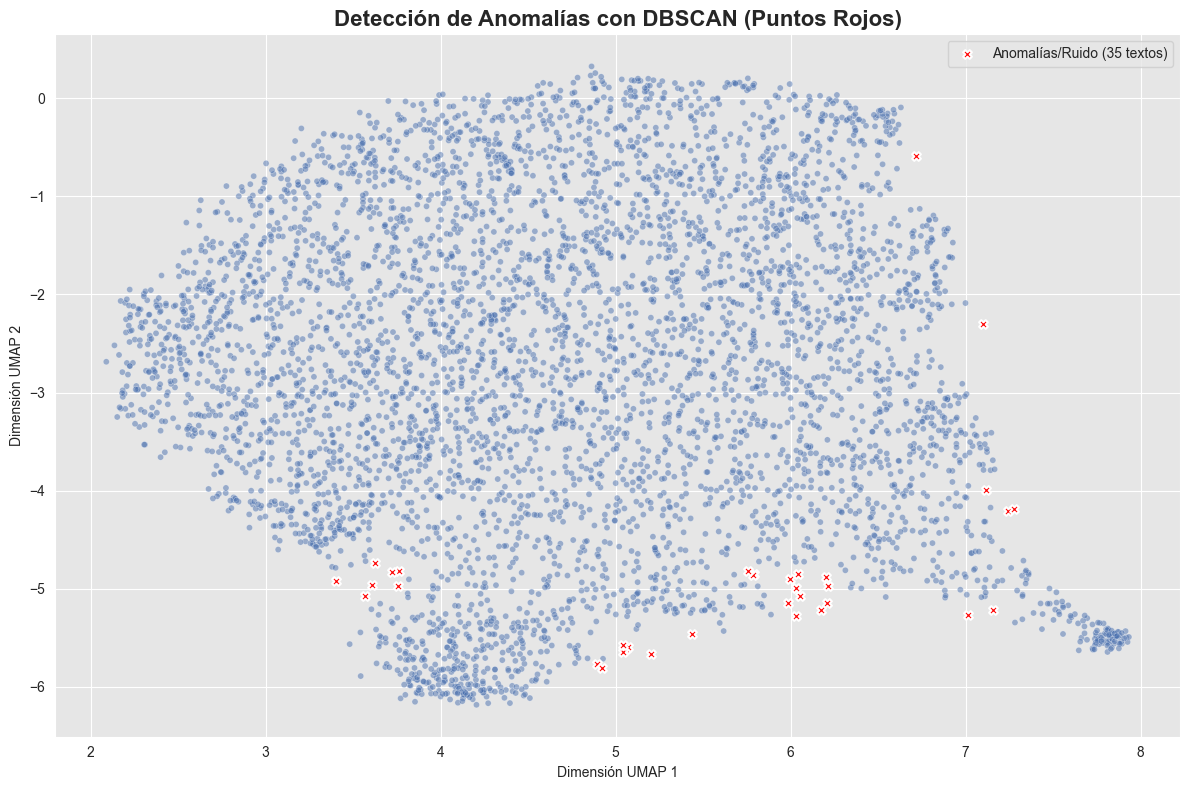


--- Ejemplos de Anomalías detectadas por DBSCAN---
  - Jajajaa cállate indio estúpido metiche.hdp que no te metas en lo que no te importa.
  - Así como te hablo che negro sucio en la cocina te frio, y el que se compre tu cara e'mono se me va el control.
  - Me das asco cobarde ctm, te escondes detrás de un teclado lamebotas de los poderosos, eres una vergüenza para tu familia vendepatria ctm
  - Jajaja qué mujer? Esa es una facha qlia, no merece respeto


In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=15)
df_test['dbscan_cluster'] = dbscan.fit_predict(embedding_2d)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='x_umap', y='y_umap',
    hue='dbscan_cluster',
    palette='deep',
    data=df_test[df_test['dbscan_cluster'] != -1],
    s=20, alpha=0.5, legend=False
)

noise_data = df_test[df_test['dbscan_cluster'] == -1]
sns.scatterplot(
    x='x_umap', y='y_umap',
    color='#FF0000',
    marker='X',   
    s=40, linewidth=1.5,
    label=f'Anomalías/Ruido ({len(noise_data)} textos)',
    data=noise_data
)

plt.title('Detección de Anomalías con DBSCAN (Puntos Rojos)', fontsize=16, fontweight='bold')
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.legend()
plt.tight_layout()
plt.show()

if len(noise_data) > 0:
    print(f"\n--- Ejemplos de Anomalías detectadas por DBSCAN---")
    example = noise_data['text'].head(4).tolist()
    for ex in example:
        print(f"  - {ex[:300]}")

### - Puntos Ciegos del nlp

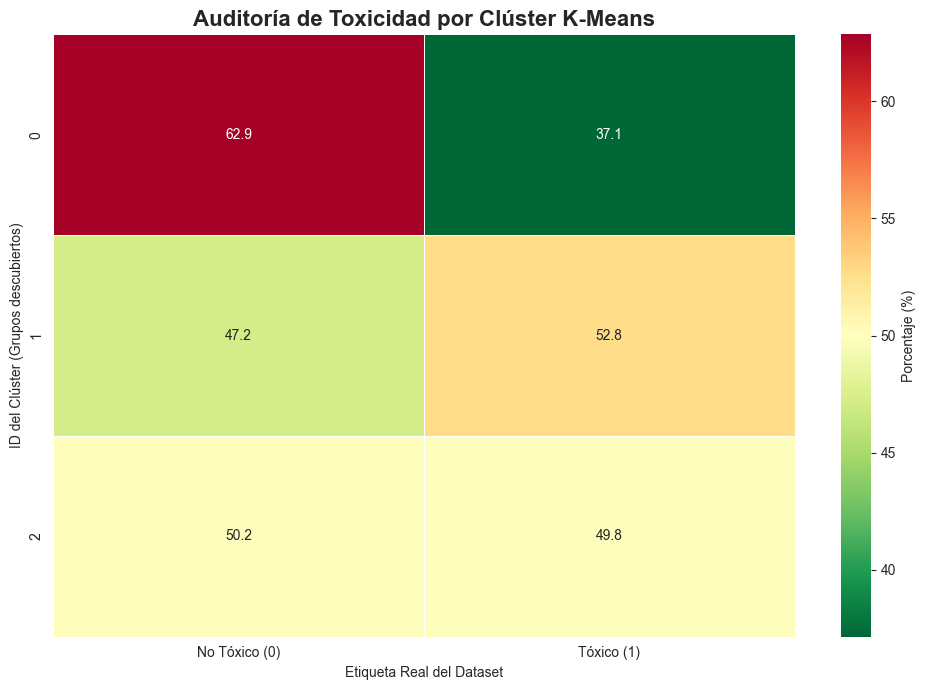

In [ ]:
labels_map = {0: 'No Tóxico (0)', 1: 'Tóxico (1)'}
crosstab_norm = pd.crosstab(
    df_test['kmeans_cluster'],
    df_test['label'].map(labels_map),
    normalize='index'
) * 100

plt.figure(figsize=(10, 7))
heatmap = sns.heatmap(
    crosstab_norm,
    annot=True,  
    fmt=".1f",   
    cmap="RdYlGn_r",
    linewidths=.5,
    cbar_kws={'label': 'Porcentaje (%)'}
)
plt.title('Auditoría de Toxicidad por Clúster K-Means', fontsize=16, fontweight='bold')
plt.ylabel('ID del Clúster (Grupos descubiertos)')
plt.xlabel('Etiqueta Real del Dataset')
plt.tight_layout()
plt.show()


### - Matriz de Confusión

/Users/31almawolf/Documents/FiltroLimpio/venv/lib/python3.11/site-packages/thinc/shims/pytorch.py:118: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type="cuda", enabled=self._mixed_precision):



--- Reporte de Clasificación ---
              precision    recall  f1-score   support

   NO_TOXICO       0.74      0.78      0.76      2500
      TOXICO       0.77      0.72      0.74      2500

    accuracy                           0.75      5000
   macro avg       0.75      0.75      0.75      5000
weighted avg       0.75      0.75      0.75      5000



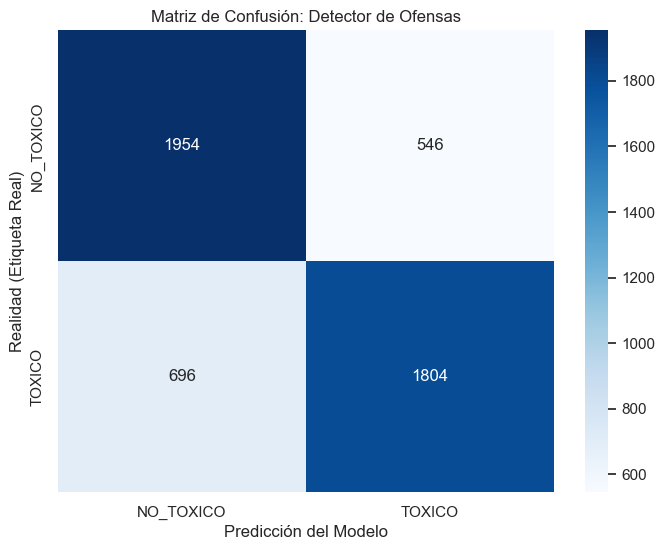

In [ ]:
sns.set_theme(style="whitegrid") 
plt.rcParams['figure.dpi'] = 100

nlp = spacy.load("nlp_español/output_es/model-best")

test_data = pd.read_csv("Test_dataset/español_test.csv")
test_data = test_data.dropna(subset=['text'])
test_data['label'] = test_data['label'].astype(int)

y_true = []
y_pred = []
true_label = ""
resultados = []

for text, label in zip(test_data['text'], test_data['label']):
    doc = nlp(text)
    pred_label = max(doc.cats, key=doc.cats.get)
    resultados.append({
        'frase': text,
        'toxic_pct': doc.cats['TOXICO'],
        'non_toxic_pct': doc.cats['NO_TOXICO']
    })

    if label == 1:
        true_label = "TOXICO"
    else:
        true_label = "NO_TOXICO"
    
    y_true.append(true_label)
    y_pred.append(pred_label)

df = pd.DataFrame(resultados)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred))

labels = ["NO_TOXICO", "TOXICO"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.title('Matriz de Confusión: Detector de Ofensas')
plt.show()

In [ ]:
import spacy
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid") 
plt.rcParams['figure.dpi'] = 100

nlp = spacy.load("nlp_español/output_es/model-best")

test_data = pd.read_csv("Test_dataset/español_test.csv")
test_data = test_data.dropna(subset=['text'])
test_data['label'] = test_data['label'].astype(int)

y_true = []
y_pred = []
true_label = ""
resultados = []

for text, label in zip(test_data['text'], test_data['label']):
    doc = nlp(text)
    pred_label = max(doc.cats, key=doc.cats.get)
    resultados.append({
        'frase': text,
        'toxic_pct': doc.cats['TOXICO'],
        'non_toxic_pct': doc.cats['NO_TOXICO']
    })

    if label == 1:
        true_label = "TOXICO"
    else:
        true_label = "NO_TOXICO"
    
    y_true.append(true_label)
    y_pred.append(pred_label)

df = pd.DataFrame(resultados)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred))

labels = ["NO_TOXICO", "TOXICO"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.title('Matriz de Confusión: Detector de Ofensas')
plt.show()

### -Dendrograma

In [ ]:
nlp = spacy.load("nlp_español/output_es/model-last")

# palabras_test = [
#     "Eres una persona increible", "Te quiero mucho", "Amistad verdadera",
#     "Eres un idiota", "Vaya basura de servicio", "Eres un inutil",
#     "Gracias por tu ayuda", "Que buen dia hace", "Te odio maldito", "No te odio", ""
# ]

# resultados = []

# for frase in palabras_test:
#     res = nlp(frase)
#     print(res.cats)
#     resultados.append({
#         'frase': frase,
#         'toxic_pct': res.cats['TOXICO'],
#         'non_toxic_pct': res.cats['NO_TOXICO']
#     })

# df = pd.DataFrame(resultados)
X = df[['toxic_pct', 'non_toxic_pct']].values
X = X + np.random.normal(0, 0.000001, X.shape)
Z = linkage(X, method='ward')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

dendrogram(Z, labels=df['frase'].values, leaf_rotation=45, ax=ax1)
ax1.set_title('Vista Normal: Separación clara Tóxico vs No Tóxico')
ax1.set_ylabel('Distancia Lineal')

dendrogram(Z, labels=df['frase'].values, leaf_rotation=45)
ax2.set_yscale("log")
ax2.set_title('Vista Logarítmica: Detalles de similitud interna')
ax2.set_ylabel('Distancia (Escala Log)')

plt.tight_layout()
plt.show()


### - Gráfica de Densidad

In [ ]:
df['clase'] = df['toxic_pct'].apply(lambda x: 'Tóxico' if x > 0.5 else 'No Tóxico')

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(data=df, x="toxic_pct", hue="clase", kde=True, stat="count")

plt.title('Distribución de Probabilidades de Toxicidad (KDE)', fontsize=14)
plt.xlabel('Probabilidad de Toxicidad (0 a 1)', fontsize=12)
plt.ylabel('Numero de frases', fontsize=12)
plt.xlim(0, 1) 

plt.show()